<a href="https://www.kaggle.com/code/manognamannala/rq4-text-feature-ablation-study?scriptVersionId=316852579" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ4: Text Feature Ablation Study

**Research question:** Does adding textual marketing information from movie overviews, keywords, and taglines improve prediction of popularity, revenue, or audience rating compared with structured metadata alone?

This Kaggle-ready notebook loads the raw CSV/Excel dataset, creates the required actual answer table(s), and saves the final figure as a PDF.

In [1]:

# =========================
# Common setup and utilities
# =========================

import os
import ast
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# Change this only if your Kaggle input folder has a different path.
# On Kaggle, this usually works automatically:
KAGGLE_INPUT_ROOT = "/kaggle/input"

OUTPUT_DIR = "/kaggle/working"
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_dataset_file():
    """
    Finds the first CSV or Excel file in Kaggle input folders.
    Also works locally if the dataset is in the current folder.
    """
    search_patterns = [
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.csv"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xlsx"),
        os.path.join(KAGGLE_INPUT_ROOT, "**", "*.xls"),
        "*.csv",
        "*.xlsx",
        "*.xls"
    ]
    files = []
    for pattern in search_patterns:
        files.extend(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError("No CSV or Excel dataset file found. Check Kaggle input path.")
    # Prefer files with movie-related names if multiple files exist.
    movie_like = [f for f in files if "movie" in os.path.basename(f).lower()]
    return movie_like[0] if movie_like else files[0]

def load_raw_dataset():
    file_path = find_dataset_file()
    print("Loading dataset from:", file_path)
    if file_path.lower().endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
    print("Shape:", df.shape)
    return df

def safe_literal_list(x):
    """
    Converts stringified Python lists like "['Drama', 'Comedy']" into actual lists.
    Returns [] for missing or invalid values.
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    x = x.strip()
    if x == "" or x == "[]":
        return []
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return [str(v).strip() for v in val if str(v).strip()]
        return []
    except Exception:
        # Fallback for comma-separated strings
        return [v.strip() for v in x.split(",") if v.strip()]

def prepare_base_dataframe(df):
    """
    Cleans and creates derived variables used across the research questions.
    """
    df = df.copy()

    # Standardize expected column names
    df.columns = [c.strip() for c in df.columns]

    # Date features
    if "release_date" in df.columns:
        df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
        df["release_year"] = df["release_date"].dt.year
        df["release_month"] = df["release_date"].dt.month
    else:
        df["release_year"] = np.nan
        df["release_month"] = np.nan

    # Ensure expected numeric columns exist
    for col in ["runtime", "popularity", "vote_average", "vote_count", "budget", "revenue"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Parse list-like columns
    for col in ["genres", "keywords", "cast", "production_companies", "production_countries", "spoken_languages"]:
        if col not in df.columns:
            df[col] = ""
        df[col + "_list"] = df[col].apply(safe_literal_list)

    # Text variables
    for col in ["overview", "keywords", "tagline", "title", "director", "language"]:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    # Derived variables
    df["genre_count"] = df["genres_list"].apply(len)
    df["keyword_count"] = df["keywords_list"].apply(len)
    df["cast_size"] = df["cast_list"].apply(len)
    df["production_company_count"] = df["production_companies_list"].apply(len)
    df["spoken_language_count"] = df["spoken_languages_list"].apply(len)
    df["overview_length"] = df["overview"].fillna("").astype(str).str.split().apply(len)
    df["tagline_length"] = df["tagline"].fillna("").astype(str).str.split().apply(len)
    df["has_tagline"] = (df["tagline"].str.strip() != "").astype(int)
    df["log_budget"] = np.log1p(df["budget"].fillna(0))
    df["log_revenue"] = np.log1p(df["revenue"].fillna(0))
    df["log_vote_count"] = np.log1p(df["vote_count"].fillna(0))

    # Combined text for TF-IDF
    df["combined_text"] = (
        df["overview"].fillna("") + " " +
        df["keywords"].fillna("") + " " +
        df["tagline"].fillna("")
    )

    # First genre for descriptive tables/charts
    df["primary_genre"] = df["genres_list"].apply(lambda x: x[0] if len(x) else "Unknown")

    return df

def add_top_genre_columns(df, top_n=15):
    """
    Multi-hot encodes the most frequent genres and adds them as columns.
    """
    df = df.copy()
    all_genres = pd.Series([g for sublist in df["genres_list"] for g in sublist])
    top_genres = all_genres.value_counts().head(top_n).index.tolist()
    for genre in top_genres:
        df[f"genre_{genre}"] = df["genres_list"].apply(lambda x: int(genre in x))
    return df, [f"genre_{g}" for g in top_genres]

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print("Saved figure:", path)
    return path

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def clean_modeling_data(df, target_col, feature_cols):
    """
    Keeps rows with non-missing target and selected features.
    """
    use_cols = list(dict.fromkeys(feature_cols + [target_col]))
    data = df[use_cols].copy()
    data = data.dropna(subset=[target_col])
    return data

def make_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features),
            ("text", TfidfVectorizer(max_features=300, stop_words="english"), "combined_text")
        ],
        remainder="drop"
    )

def make_structured_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=30))
            ]), categorical_features)
        ],
        remainder="drop"
    )


Loading dataset from: /kaggle/input/datasets/manognamannala/movies-analyzing-dataset/movies dataset.csv
Shape: (3053, 22)
Saved table: /kaggle/working/RQ4_text_ablation_performance.csv
Saved table: /kaggle/working/RQ4_text_ablation_r2_improvement.csv
Saved table: /kaggle/working/RQ4_actual_answer.csv
Saved figure: /kaggle/working/RQ4_figure_text_feature_ablation.pdf


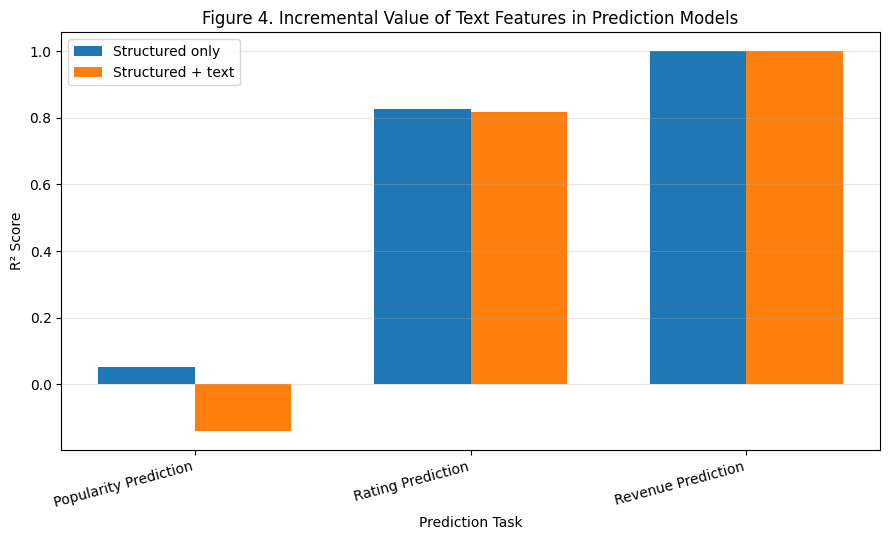

,prediction_task,target_variable,feature_set,r2,rmse,mae
0,Popularity Prediction,popularity,Structured only,0.053391,2.685034,0.311358
1,Popularity Prediction,popularity,Structured + text,-0.140255,2.946901,0.358290
2,Revenue Prediction,log_revenue,Structured only,0.999418,0.092258,0.042472
3,Revenue Prediction,log_revenue,Structured + text,0.999351,0.097493,0.045287
4,Rating Prediction,vote_average,Structured only,0.826354,1.262897,0.836580
5,Rating Prediction,vote_average,Structured + text,0.817313,1.295357,0.865106


In [2]:

df_raw = load_raw_dataset()
df = prepare_base_dataframe(df_raw)
df, genre_cols = add_top_genre_columns(df)

numeric_base = [
    "runtime", "release_year", "release_month", "genre_count", "keyword_count",
    "cast_size", "production_company_count", "spoken_language_count",
    "overview_length", "tagline_length", "has_tagline",
    "log_budget", "log_revenue", "log_vote_count"
] + genre_cols

categorical_features = ["language", "director", "primary_genre"]

tasks = [
    ("Popularity Prediction", "popularity"),
    ("Revenue Prediction", "log_revenue"),
    ("Rating Prediction", "vote_average")
]

rows = []

for task_name, target in tasks:
    # Revenue task uses revenue > 0 for meaningful log revenue modeling.
    task_df = df[df["revenue"] > 0].copy() if target == "log_revenue" else df.copy()

    numeric_features = numeric_base.copy()
    if target != "popularity":
        numeric_features += ["popularity"]
    if target != "vote_average":
        numeric_features += ["vote_average"]

    structured_features = numeric_features + categorical_features
    text_features = structured_features + ["combined_text"]

    data = clean_modeling_data(task_df, target, text_features)
    X = data[text_features]
    y = data[target]

    if len(data) < 20:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    model = GradientBoostingRegressor(random_state=RANDOM_STATE)

    # Structured-only model
    structured_pre = make_structured_preprocessor(numeric_features, categorical_features)
    structured_pipe = Pipeline([
        ("preprocess", structured_pre),
        ("model", model)
    ])
    structured_pipe.fit(X_train[structured_features], y_train)
    pred_structured = structured_pipe.predict(X_test[structured_features])

    rows.append({
        "prediction_task": task_name,
        "target_variable": target,
        "feature_set": "Structured only",
        "r2": r2_score(y_test, pred_structured),
        "rmse": rmse(y_test, pred_structured),
        "mae": mean_absolute_error(y_test, pred_structured)
    })

    # Structured + text model
    text_pre = make_preprocessor(numeric_features, categorical_features)
    text_pipe = Pipeline([
        ("preprocess", text_pre),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ])
    text_pipe.fit(X_train[text_features], y_train)
    pred_text = text_pipe.predict(X_test[text_features])

    rows.append({
        "prediction_task": task_name,
        "target_variable": target,
        "feature_set": "Structured + text",
        "r2": r2_score(y_test, pred_text),
        "rmse": rmse(y_test, pred_text),
        "mae": mean_absolute_error(y_test, pred_text)
    })

table = pd.DataFrame(rows)
save_table(table, "RQ4_text_ablation_performance.csv")

pivot = table.pivot(index="prediction_task", columns="feature_set", values="r2").reset_index()
pivot["r2_improvement"] = pivot["Structured + text"] - pivot["Structured only"]
save_table(pivot, "RQ4_text_ablation_r2_improvement.csv")

avg_improvement = pivot["r2_improvement"].mean()
answer = pd.DataFrame([{
    "research_question": "RQ4",
    "actual_answer": f"Adding overview, keyword, and tagline text changed average R² by {avg_improvement:.3f} across the prediction tasks. Positive values indicate that marketing text improved prediction.",
    "average_r2_improvement": avg_improvement
}])
save_table(answer, "RQ4_actual_answer.csv")

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(pivot))
width = 0.35
ax.bar(x - width/2, pivot["Structured only"], width, label="Structured only")
ax.bar(x + width/2, pivot["Structured + text"], width, label="Structured + text")
ax.set_title("Figure 4. Incremental Value of Text Features in Prediction Models")
ax.set_xlabel("Prediction Task")
ax.set_ylabel("R² Score")
ax.set_xticks(x)
ax.set_xticklabels(pivot["prediction_task"], rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, "RQ4_figure_text_feature_ablation.pdf")
plt.show()

table
